# IPCA – Itens (IBGE/SIDRA 7060)

Este notebook apresenta:

**1. O que são os itens do IPCA**  
**2. Como o IBGE organiza a tabela 7060**  
**3. Execução do pipeline `ipca_itens`**  
**4. Consulta ao banco de dados (`bcb.ipca_itens`)**  
**5. Gráficos e análises exploratórias por item**  

Vamos começar entendendo o conceito.

# 1. O que são os itens do IPCA?

O **IPCA (Índice Nacional de Preços ao Consumidor Amplo)** é estruturado em:

- grupos  
- subgrupos  
- **itens (nível 4)**  
- subitens  

Os **itens** representam categorias intermediárias, como:

- Cereais, leguminosas e oleaginosas  
- Carnes  
- Leite e derivados  
- Energia elétrica residencial  

Trabalhar com itens permite:

- análises setoriais mais amplas  
- decomposição da inflação por blocos de produtos  
- identificação de pressões inflacionárias por categoria

# 2. Tabela 7060 – IPCA por itens

A tabela 7060 do SIDRA traz o IPCA por:

- Brasil (nível nacional)  
- grupos, subgrupos, itens e subitens  

As variáveis que usamos aqui são:

- **63** → variação mensal (%), chamada `indice`  
- **66** → peso do item no índice, chamada `peso`  

Nosso pipeline monta a tabela `bcb.ipca_itens` com:

- `date`  
- `indice`  
- `peso`  
- `category` (código numérico de 4 dígitos)  
- `category_name` (descrição do item)

# 3. Ajustar o PYTHONPATH para importar `src/`

In [3]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)
print("PYTHONPATH atualizado:", ROOT)

PYTHONPATH atualizado: /home/moacir/projects/ml/analytics/inflation


# 4. Importações

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipelines.ipca_itens import run_ipca_itens
from src.database.connection import engine

pd.set_option("display.float_format", "{:.6f}".format)

# 5. Executar pipeline IPCA itens (IBGE – tabela 7060)

Isso irá:
- consultar a tabela 7060 do SIDRA  
- baixar as variáveis 63 (Indice) e 66 (Peso)  
- filtrar apenas itens (nível 4)  
- criar/atualizar a tabela `bcb.ipca_itens`  
- inserir todos os dados no PostgreSQL

In [5]:
run_ipca_itens()

2026-04-20 19:48:59,201 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=7060, variavel=63, periodo=all
2026-04-20 19:49:00,900 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.
2026-04-20 19:49:00,922 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=7060, variavel=66, periodo=all
2026-04-20 19:49:02,758 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.


Tabela bcb.ipca_itens atualizada com sucesso!


,date,indice,peso,category,category_name
0,2020-01-01,0.750000,0.692700,1101,"Cereais, leguminosas e oleaginosas"
1,2020-01-01,0.900000,0.449400,1102,"Farinhas, féculas e massas"
2,2020-01-01,7.810000,0.528000,1103,"Tubérculos, raízes e legumes"
3,2020-01-01,0.740000,0.618900,1104,Açúcares e derivados
4,2020-01-01,2.520000,0.181000,1105,Hortaliças e verduras
...,...,...,...,...,...
3820,2026-03-01,0.000000,4.785500,8101,Cursos regulares
3821,2026-03-01,-0.390000,0.559000,8102,Leitura
3822,2026-03-01,0.350000,0.140800,8103,Papelaria
3823,2026-03-01,0.370000,0.818200,8104,Cursos diversos


# 6. Verificar tabelas existentes no schema `bcb`

In [7]:
pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'bcb'
ORDER BY table_name;
""", engine)

,table_name
0,ipca
1,ipca_itens
2,ipca_subitens
3,selic_meta
4,selic_over


# 7. Carregar dados de IPCA itens

In [8]:
query_itens = """
select *
from bcb.ipca_itens
order by date desc, category;
"""

df = pd.read_sql(query_itens, engine)
df.head()

,date,indice,peso,category,category_name
0,2026-03-01,2.780000,0.685100,1101,"Cereais, leguminosas e oleaginosas"
1,2026-03-01,0.790000,0.474500,1102,"Farinhas, féculas e massas"
2,2026-03-01,16.780000,0.658200,1103,"Tubérculos, raízes e legumes"
3,2026-03-01,-0.630000,0.801900,1104,Açúcares e derivados
4,2026-03-01,2.190000,0.259700,1105,Hortaliças e verduras


# 8. Primeiros registros

In [9]:
df.tail(20)

,date,indice,peso,category,category_name
3805,2020-01-01,-0.260000,1.197500,4201,Calçados e acessórios
3806,2020-01-01,0.690000,0.199600,4301,Joias e bijuterias
3807,2020-01-01,-0.180000,0.055100,4401,Tecidos e armarinho
3808,2020-01-01,-0.790000,3.329700,5101,Transporte público
3809,2020-01-01,0.240000,11.185300,5102,Veículo próprio
3810,2020-01-01,1.080000,6.082900,5104,Combustíveis (veículos)
3811,2020-01-01,0.330000,3.480500,6101,Produtos farmacêuticos
3812,2020-01-01,-0.730000,0.309400,6102,Produtos óticos
3813,2020-01-01,0.220000,1.153600,6201,Serviços médicos e dentários
3814,2020-01-01,0.400000,0.626100,6202,Serviços laboratoriais e hospitalares


# 9. Estatísticas básicas

In [10]:
df.describe()

,date,indice,peso
count,3825,3825.000000,3825.000000
mean,2023-01-30 22:43:12,0.520118,1.960784
min,2020-01-01 00:00:00,-16.330000,0.051800
25%,2021-07-01 00:00:00,-0.040000,0.500600
50%,2023-02-01 00:00:00,0.380000,1.041100
75%,2024-09-01 00:00:00,0.920000,2.953200
max,2026-03-01 00:00:00,16.800000,11.812800
std,NaN,1.934418,2.308594


# 10. Itens com maior peso médio

Aqui vemos quais itens têm maior relevância estrutural no IPCA.

In [11]:
top_peso = (
    df.groupby(["category", "category_name"])["peso"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

top_peso

,category,category_name,peso
0,5102,Veículo próprio,11.368481
1,2101,Aluguel e taxas,7.720484
2,7101,Serviços pessoais,6.333281
3,5104,Combustíveis (veículos),6.306137
4,1201,Alimentação fora do domicílio,5.875701
5,9101,Comunicação,5.075415
6,8101,Cursos regulares,4.475969
7,2202,Energia elétrica residencial,4.203493
8,6301,Higiene pessoal,3.929148
9,6203,Plano de saúde,3.920041


# 11. Evolução da variação mensal de um item específico

Vamos escolher um item de interesse (por exemplo, carnes) e analisar sua trajetória.

In [20]:
filtro = "carne"

item = df[df["category_name"].str.contains(filtro, case=False, na=False)]

item.head()

,date,indice,peso,category,category_name
6,2026-03-01,1.730000,2.782500,1107,Carnes
8,2026-03-01,0.080000,0.605600,1109,Carnes e peixes industrializados
57,2026-02-01,0.580000,2.784900,1107,Carnes
59,2026-02-01,0.750000,0.605200,1109,Carnes e peixes industrializados
108,2026-01-01,0.840000,2.770800,1107,Carnes


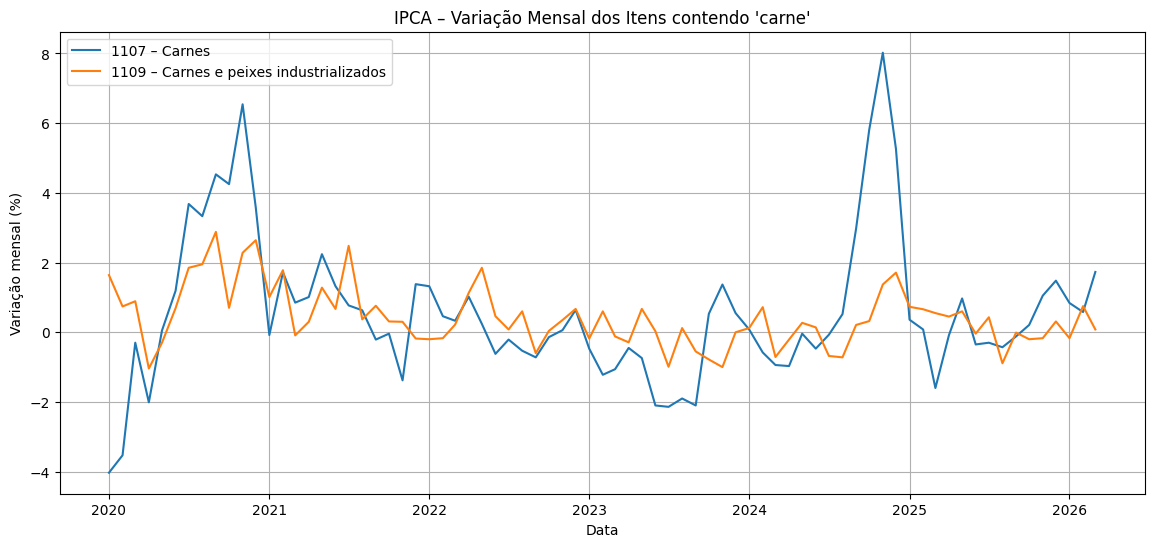

In [21]:
plt.figure(figsize=(14, 6))
for cat, g in item.groupby("category"):
    plt.plot(g["date"], g["indice"], label=f"{cat} – {g['category_name'].iloc[0]}")

plt.title(f"IPCA – Variação Mensal dos Itens contendo '{filtro}'")
plt.xlabel("Data")
plt.ylabel("Variação mensal (%)")
plt.grid(True)
plt.legend()
plt.show()

# 12. Heatmap de variação mensal – últimos 12 meses

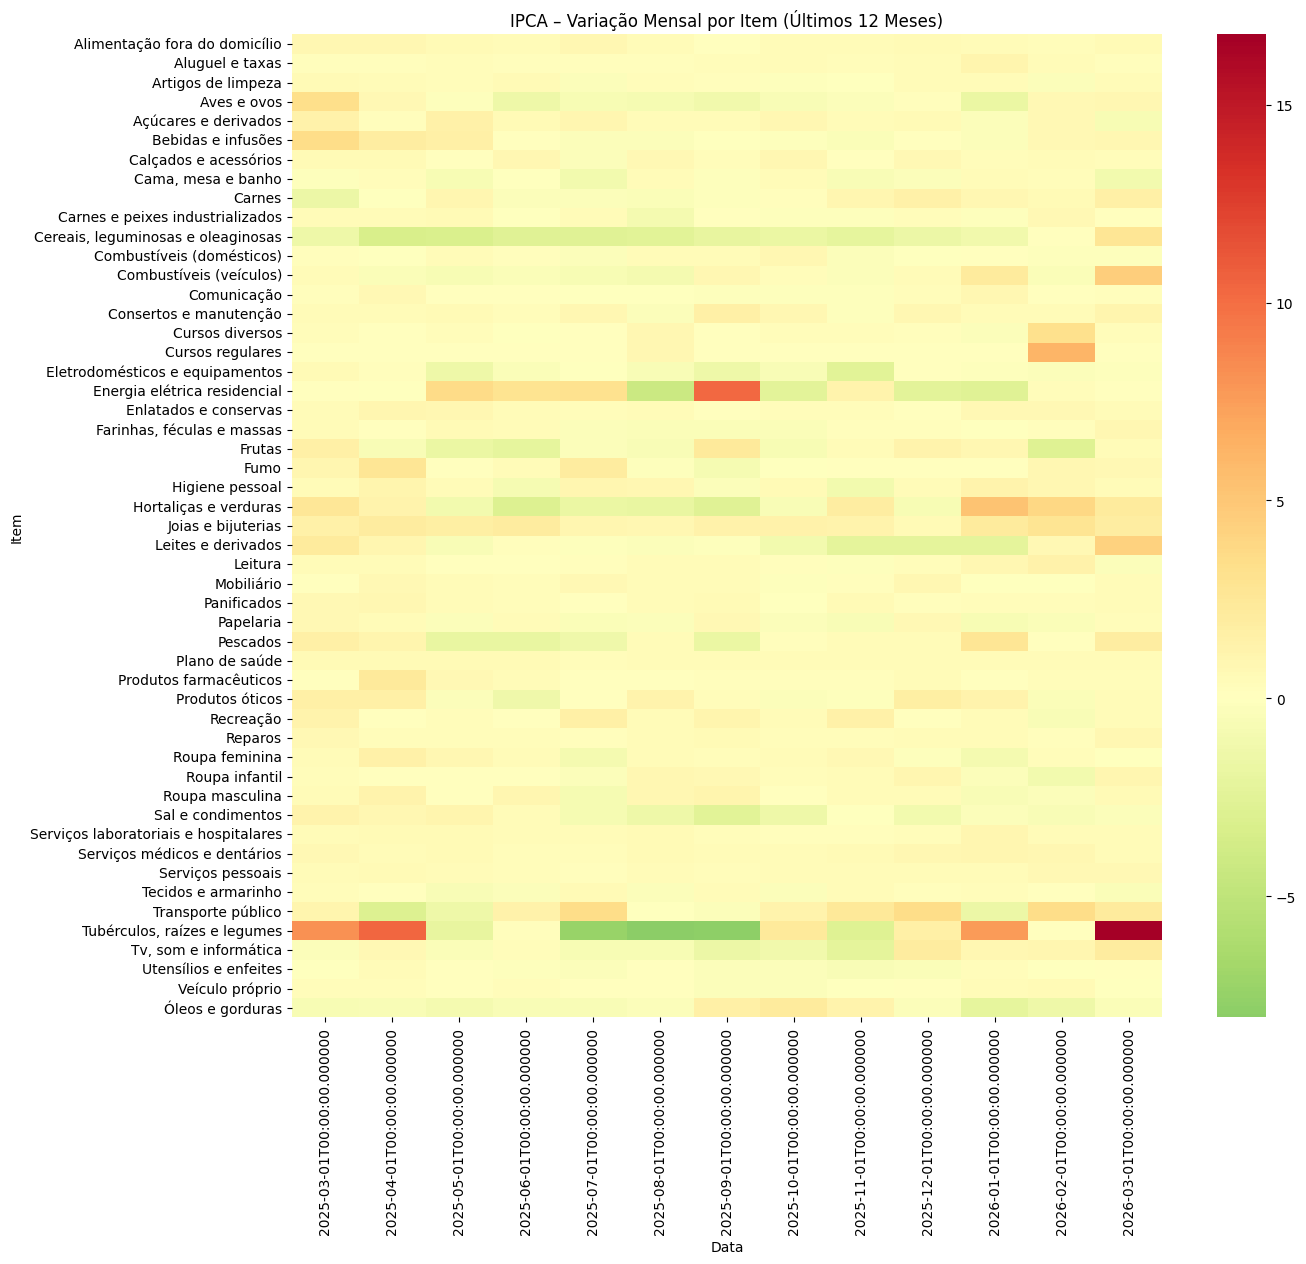

In [ ]:

df_recent = df[df["date"] >= df["date"].max() - pd.offsets.DateOffset(months=12)]

pivot_hm = df_recent.pivot_table(
    index="category_name",
    columns="date",
    values="indice"
)

plt.figure(figsize=(14, max(6, len(pivot_hm) * 0.25)))
sns.heatmap(
    pivot_hm,
    cmap="RdYlGn_r",
    center=0,
    annot=False
)
plt.title("IPCA – Variação Mensal por Item (Últimos 12 Meses)")
plt.xlabel("Data")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

# 13. Distribuição da variação mensal por item

Aqui avaliamos a dispersão da inflação entre itens em um mês recente.

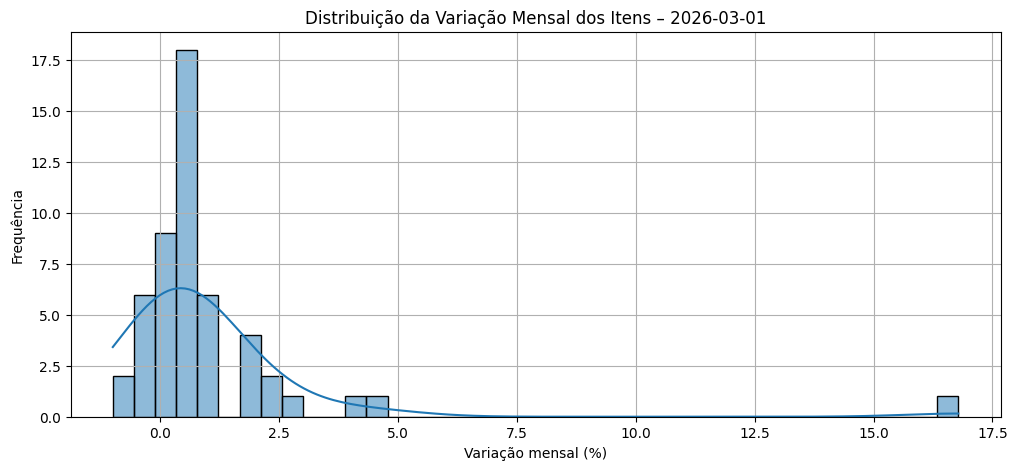

In [23]:
ultimo_mes = df["date"].max()
df_ult = df[df["date"] == ultimo_mes]

plt.figure(figsize=(12, 5))
sns.histplot(df_ult["indice"], bins=40, kde=True)
plt.title(f"Distribuição da Variação Mensal dos Itens – {ultimo_mes.date()}")
plt.xlabel("Variação mensal (%)")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

# 14. Conclusões

- A tabela `bcb.ipca_itens` traz o IPCA no nível intermediário (itens).  
- As colunas `indice` e `peso` permitem análises de contribuição e relevância de cada item.  
- A estrutura `category` (código) + `category_name` (descrição) facilita junções e painéis.  
- Este pipeline é a base para:
  - decomposição da inflação por grupo e item  
  - análises setoriais  
  - construção de núcleos e medidas alternativas  

Próximos passos:
- Integrar esta tabela com o IPCA geral (`bcb.ipca`)  
- Construir decomposições por grupo, subgrupo e item  
- Criar dashboards e relatórios automatizados de inflação por item